In [1]:
import copy
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from arch import arch_model

np.random.seed(1)
torch.manual_seed(1)
device = "cuda" if torch.cuda.is_available() else "cpu"


In [2]:
data = pd.read_csv("IBM.csv")
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date").reset_index(drop=True)
returns = 100 * np.log(data["Close_IBM"]).diff().dropna().to_numpy().astype("float32")
dates = data.loc[data["Close_IBM"].shift(1).notna(), "Date"].reset_index(drop=True)

test_size = 30
context = 30
train = returns[:-test_size]
test = returns[-test_size:]
test_dates = dates.iloc[-test_size:]


In [3]:
def qlike(realized, variance):
    variance = np.maximum(variance, 1e-8)
    return np.mean(np.log(variance) + realized / variance)

garch = arch_model(train, mean="Constant", vol="GARCH", p=1, q=1, dist="t", rescale=False).fit(disp="off")

garch_variances = []
history = list(train)
for value in test:
    fit = arch_model(np.asarray(history), mean="Constant", vol="GARCH", p=1, q=1, dist="t", rescale=False).fit(disp="off")
    garch_variances.append(float(fit.forecast(horizon=1, reindex=False).variance.iloc[-1, 0]))
    history.append(float(value))
garch_variances = np.asarray(garch_variances)
garch_volatility = np.sqrt(garch_variances)


In [4]:
squared = returns ** 2
rv5 = pd.Series(squared).rolling(5).mean().to_numpy()
rv22 = pd.Series(squared).rolling(22).mean().to_numpy()
har_x, har_y = [], []
for i in range(22, len(train)):
    har_x.append([rv5[i - 1], rv22[i - 1], squared[i - 1]])
    har_y.append(squared[i])
har_x = np.asarray(har_x)
har_y = np.asarray(har_y)
har_beta = np.linalg.lstsq(np.column_stack([np.ones(len(har_x)), har_x]), har_y, rcond=None)[0]

har_variances = []
history = list(train)
for value in test:
    h = np.asarray(history) ** 2
    features = [h[-5:].mean(), h[-22:].mean(), h[-1]]
    har_variances.append(max(float(np.r_[1.0, features] @ har_beta), 1e-8))
    history.append(float(value))
har_variances = np.asarray(har_variances)
har_volatility = np.sqrt(har_variances)


In [5]:
scale = np.std(train)
normalized = train / scale
validation_size = max(60, int(0.15 * len(normalized)))
fit_values = normalized[:-validation_size]
validation_values = normalized[-validation_size:]

def windows(values, length):
    x, y = [], []
    for i in range(length, len(values)):
        x.append(values[i-length:i])
        y.append(values[i])
    return torch.tensor(np.asarray(x), dtype=torch.float32), torch.tensor(np.asarray(y), dtype=torch.float32)

train_x, train_y = windows(fit_values, context)
validation_x, validation_y = windows(np.r_[fit_values[-context:], validation_values], context)
loader = DataLoader(TensorDataset(train_x, train_y), batch_size=64, shuffle=True)


In [6]:
class Transformer(nn.Module):
    def __init__(self, length=30, d=16, heads=2):
        super().__init__()
        self.input = nn.Linear(1, d)
        position = torch.arange(length).unsqueeze(1)
        frequency = torch.exp(torch.arange(0, d, 2) * (-math.log(10000.0) / d))
        encoding = torch.zeros(length, d)
        encoding[:, 0::2] = torch.sin(position * frequency)
        encoding[:, 1::2] = torch.cos(position * frequency)
        self.register_buffer("encoding", encoding.unsqueeze(0))
        layer = nn.TransformerEncoderLayer(d, heads, 2*d, 0.0, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, 1)
        self.norm = nn.LayerNorm(d)
        self.output = nn.Linear(d, 2)

    def forward(self, x, target=None):
        x = self.input(x.unsqueeze(-1)) + self.encoding[:, :x.shape[1]]
        p = self.output(self.norm(self.encoder(x)[:, -1]))
        distribution = torch.distributions.StudentT(5.0, p[:, 0], torch.nn.functional.softplus(p[:, 1]) + 1e-4)
        loss = None if target is None else -distribution.log_prob(target).mean()
        return distribution, loss


C:\Users\trist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


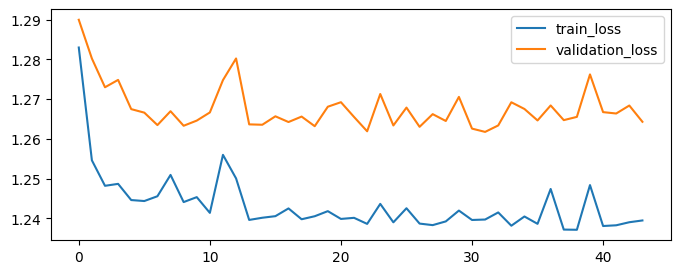

In [7]:
model = Transformer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
best_state = None
best_validation = float("inf")
patience = 12
stale = 0
training_history = []

for epoch in range(150):
    model.train()
    for x, y in loader:
        _, loss = model(x.to(device), y.to(device))
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    model.eval()
    with torch.no_grad():
        _, train_loss = model(train_x.to(device), train_y.to(device))
        _, validation_loss = model(validation_x.to(device), validation_y.to(device))
    train_loss, validation_loss = train_loss.item(), validation_loss.item()
    training_history.append([train_loss, validation_loss])
    if validation_loss < best_validation:
        best_validation = validation_loss
        best_state = copy.deepcopy(model.state_dict())
        stale = 0
    else:
        stale += 1
    if stale >= patience:
        break

model.load_state_dict(best_state)
pd.DataFrame(training_history, columns=["train_loss", "validation_loss"]).plot(figsize=(8, 3))
plt.show()


GARCH QLIKE          3.844401
HAR-RV QLIKE         3.766261
Transformer QLIKE    5.064362
dtype: float64


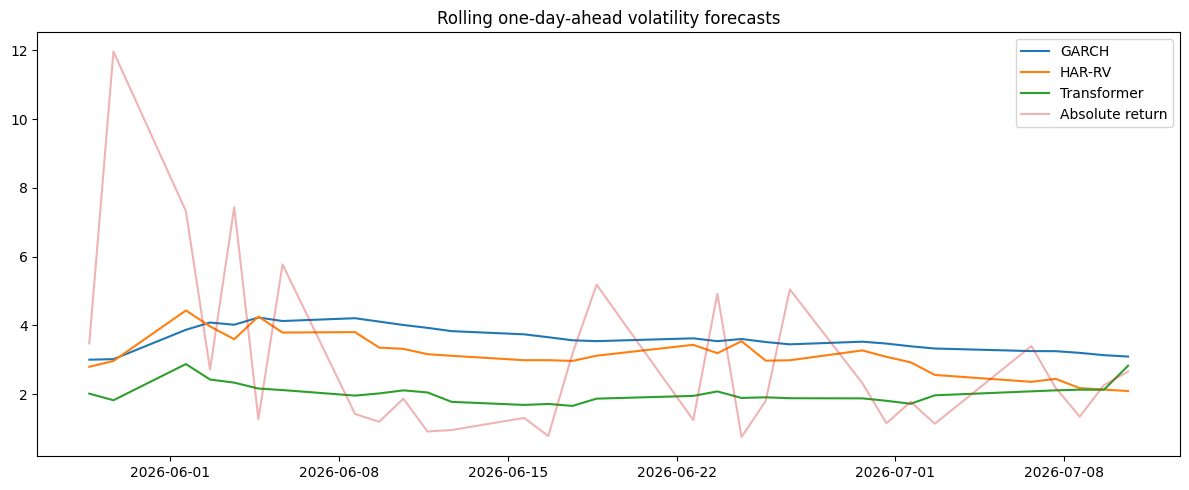

,Date,Squared return,GARCH volatility,HAR-RV volatility,Transformer volatility
0,2026-05-28 16:00:00,12.064882,3.000027,2.794364,2.012089
1,2026-05-29 16:00:00,143.137360,3.014946,2.962227,1.820277
2,2026-06-01 16:00:00,53.597797,3.869709,4.431827,2.872649
3,2026-06-02 16:00:00,7.357091,4.080991,3.967719,2.422355
4,2026-06-03 16:00:00,55.325890,4.016838,3.594887,2.332513
5,2026-06-04 16:00:00,1.615462,4.226970,4.255362,2.160032
6,2026-06-05 16:00:00,33.336208,4.125217,3.789909,2.115991
7,2026-06-08 16:00:00,2.020299,4.206497,3.802022,1.954748
8,2026-06-09 16:00:00,1.423010,4.108074,3.351454,2.018433
9,2026-06-10 16:00:00,3.482022,4.009628,3.314703,2.106981


In [8]:
@torch.no_grad()
def transformer_forecast(history, horizon):
    model.eval()
    values = list((np.asarray(history) / scale).astype("float32"))
    variances = []
    for _ in range(horizon):
        x = torch.tensor(values[-context:], dtype=torch.float32, device=device).unsqueeze(0)
        distribution, _ = model(x)
        df = distribution.df.item()
        predicted_variance = distribution.scale.item() ** 2 * df / (df - 2)
        variances.append(predicted_variance * scale ** 2)
        values.append(distribution.sample().item())
    return np.asarray(variances)

transformer_variances = transformer_forecast(train, test_size)
transformer_volatility = np.sqrt(transformer_variances)
comparison = pd.DataFrame({"Date": test_dates.to_numpy(), "Squared return": test ** 2, "GARCH volatility": garch_volatility, "HAR-RV volatility": har_volatility, "Transformer volatility": transformer_volatility})
scores = pd.Series({"GARCH QLIKE": qlike(test ** 2, garch_variances), "HAR-RV QLIKE": qlike(test ** 2, har_variances), "Transformer QLIKE": qlike(test ** 2, transformer_variances)})
print(scores)

plt.figure(figsize=(12, 5))
plt.plot(comparison["Date"], comparison["GARCH volatility"], label="GARCH")
plt.plot(comparison["Date"], comparison["HAR-RV volatility"], label="HAR-RV")
plt.plot(comparison["Date"], comparison["Transformer volatility"], label="Transformer")
plt.plot(comparison["Date"], np.sqrt(comparison["Squared return"]), alpha=0.35, label="Absolute return")
plt.legend()
plt.title("Rolling one-day-ahead volatility forecasts")
plt.tight_layout()
plt.show()
comparison
